In [1]:
from pathlib import Path
from matplotlib import pyplot as plt
import numpy as np
from astropy.visualization import hist
from astropy import units as u
from astropy.nddata import CCDData
import ccdproc as ccdp
from astropy.io import fits

# Set the path to your dark frames directory
data_path = Path(r'C:/Users/Observatory/Exo/Data/NGC2419/badpixels')

# Load the master dark frames
dark_200s = CCDData.read(data_path / 'masterdark_200s.fits', unit='adu')
dark_60s = CCDData.read(data_path / 'masterdark_60s.fits', unit='adu')


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


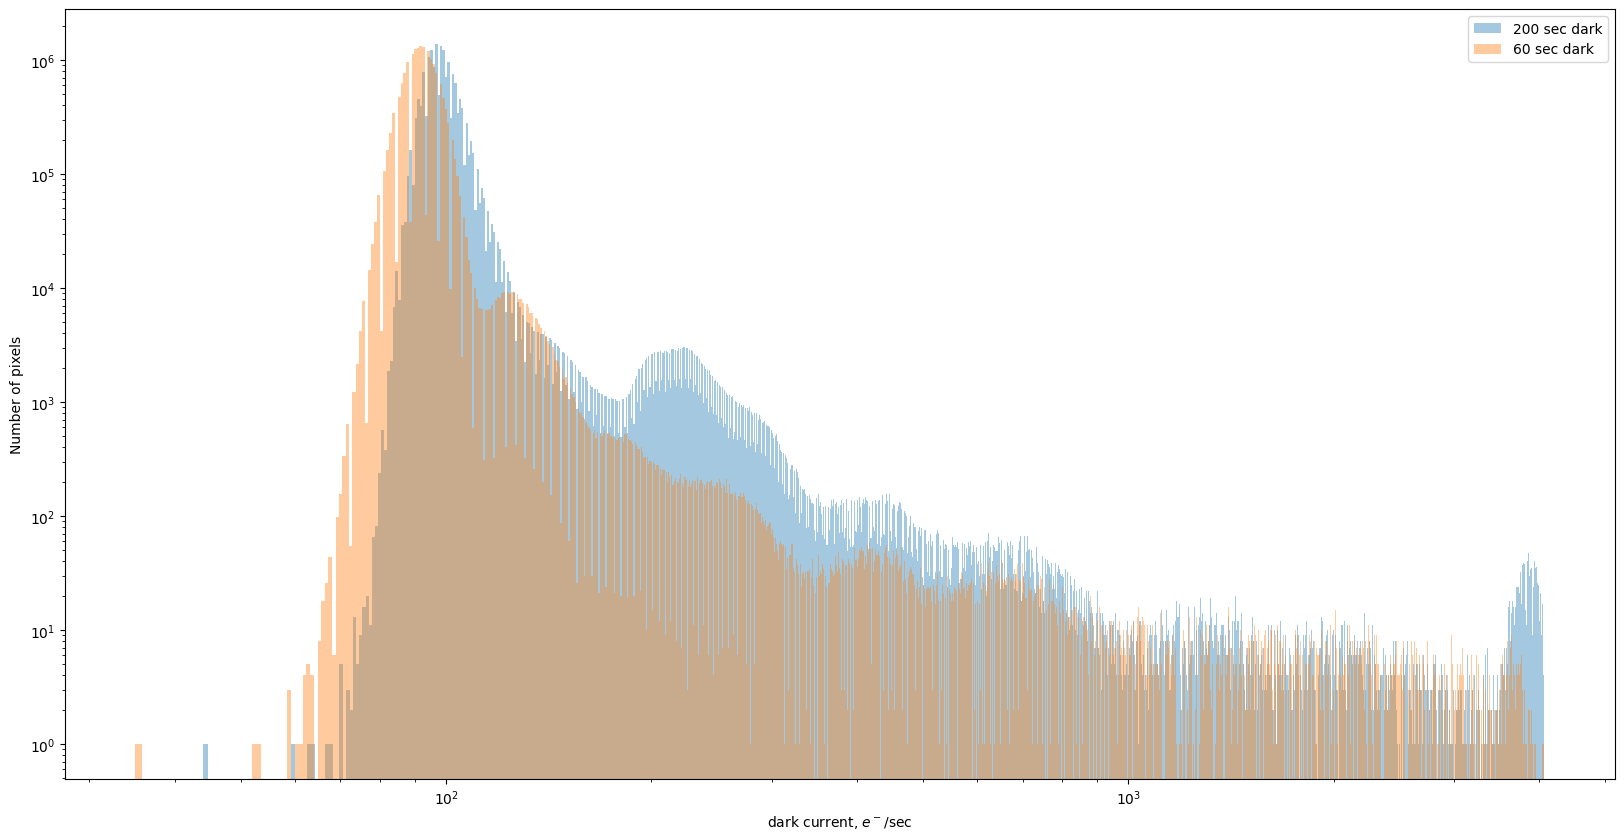

In [2]:
plt.figure(figsize=(20, 10))

hist(dark_200s.data.flatten(), bins=5000, density=False, label='200 sec dark', alpha=0.4)
hist(dark_60s.data.flatten(), bins=5000, density=False, label='60 sec dark', alpha=0.4)
plt.xlabel('dark current, $e^-$/sec')
plt.ylabel('Number of pixels')
plt.loglog()
plt.legend();

In [3]:
#gain =1.0 * u.electron / u.adu
##gain = 1.5 * u.electron / u.adu

#dark_200s = dark_200s.multiply(gain).divide(200 * u.second)
#dark_60s = dark_60s.multiply(gain).divide(60 * u.second)

#dark_200s.unit = u.electron / u.second
#dark_60s.unit = u.electron / u.second

In [4]:
#dark_60s_quantity = dark_60s.data * dark_60s.unit
#threshold = 1 * u.electron / u.second#

#hot_pixels = (dark_60s_quantity > threshold)
#Why only use the shorter dark frame?
##Hot pixels typically show consistently high dark current across all exposure times. So if a pixel is hot in a short exposure (like 5s), it will be even more pronounced in a longer one
##(like 60s). Using dark_5s.data > 1 is a conservative and efficient way to identify hot pixels. You're likely to catch the ones that would also be high in the 60s frame, but you avoid 
## selecting pixels that only appear high due to statistical noise or cosmic rays in the longer exposure.

##You could use dark_60s.data > 1 as well, but that might:
##Select more pixels (including more noise).
##Include transient events or outliers that are not truly hot pixels.
##So in short, a low-threshold in a short exposure is a robust way to detect persistently hot pixels.

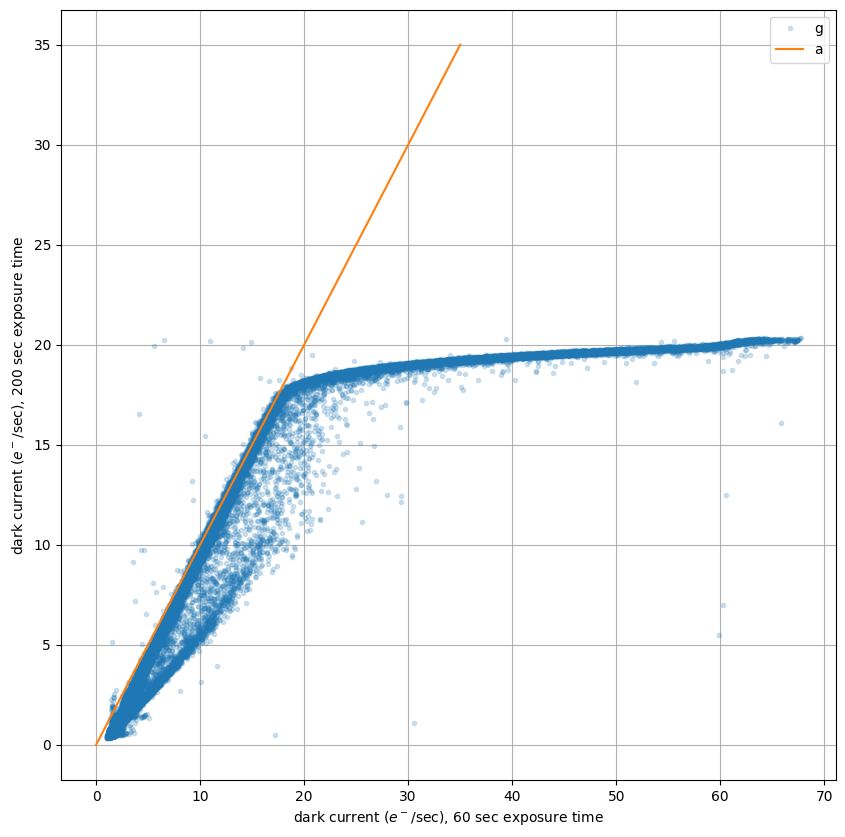

In [5]:
#plt.figure(figsize=(10, 10))
#plt.plot(dark_60s.data[hot_pixels].flatten(), dark_200s.data[hot_pixels].flatten(), '.', alpha=0.2, label='Data')
#plt.xlabel("dark current ($e^-$/sec), 60 sec exposure time")
#plt.ylabel("dark current ($e^-$/sec), 200 sec exposure time")

#plt.plot([0, 35], [0, 35], label='Ideal relationship')
#plt.grid()
#plt.legend('gain=5.0');
#plt.savefig(data_path / 'hot_pixels_comparison.png', dpi=300, bbox_inches='tight')


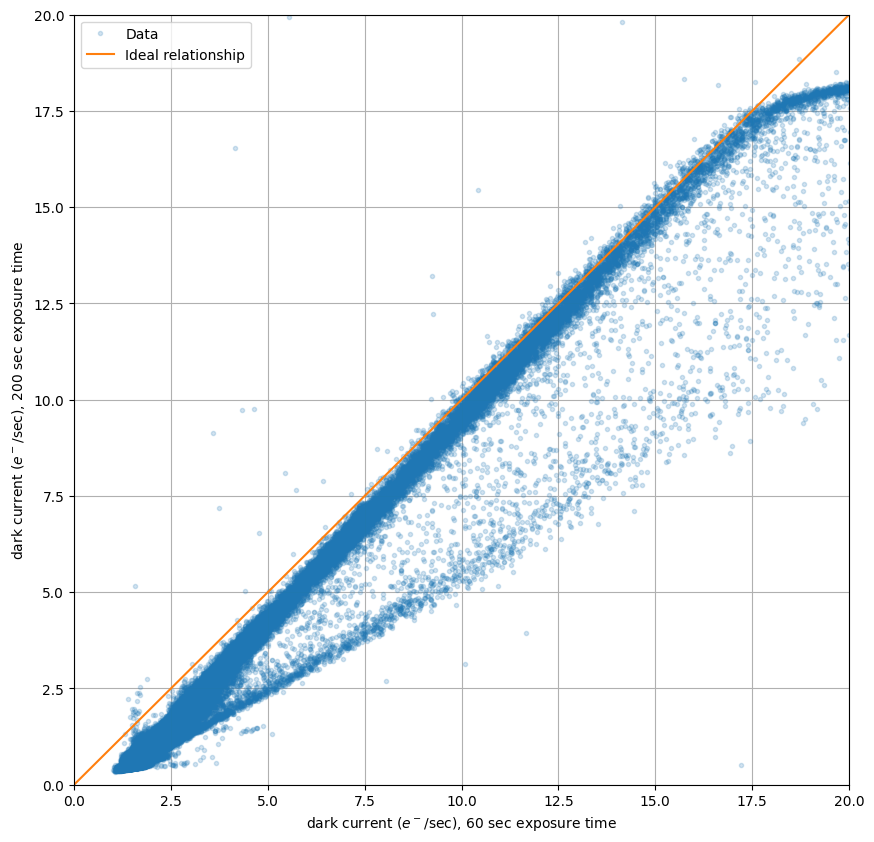

In [6]:
#plt.figure(figsize=(10, 10))
#plt.plot(dark_60s.data[hot_pixels].flatten(), dark_200s.data[hot_pixels].flatten(), '.', alpha=0.2, label='Data')
#plt.xlabel("dark current ($e^-$/sec), 60 sec exposure time")
#plt.ylabel("dark current ($e^-$/sec), 200 sec exposure time")
#plt.plot([0, 4096], [0, 4096], label='Ideal relationship')
#plt.grid()
#plt.xlim(0, 20)
#plt.ylim(0, 20)
#plt.legend();

Number of hot pixels: 901
Existing mask_from_dark.fits file deleted.
Mask saved to mask_from_dark.fits
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]


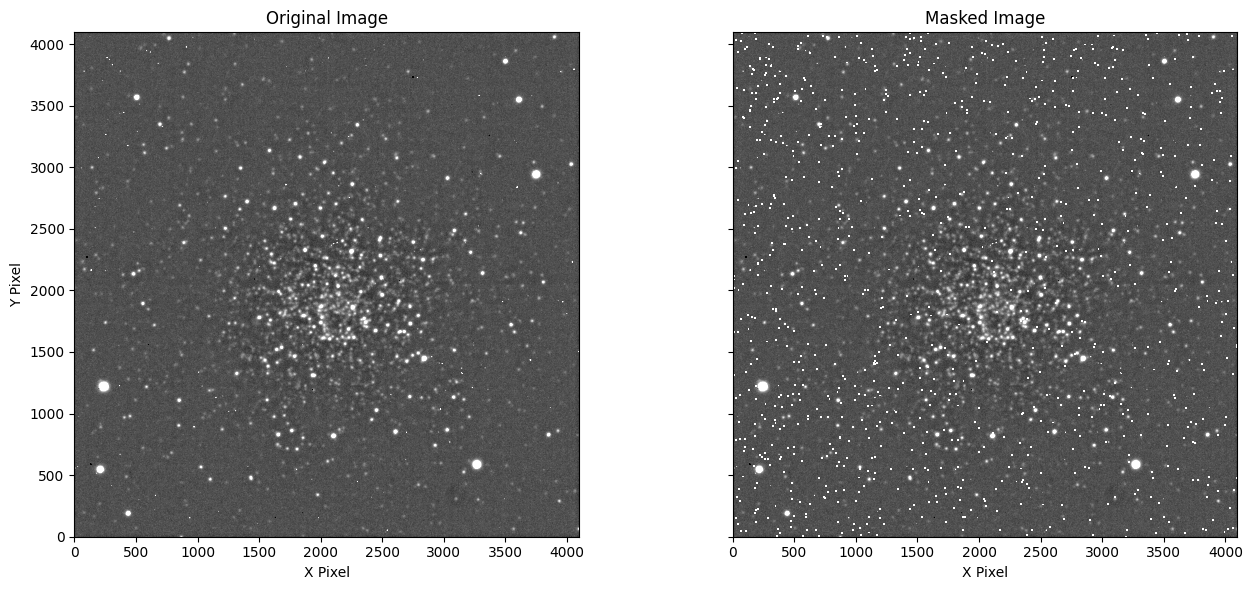

In [15]:
import astropy.io.fits as fits
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from astropy import units as u
from astropy.nddata import CCDData
import os  # Import the os module
import time # Import the time module

data_path = Path(r'C:/Users/Observatory/Exo/Data/NGC2419/badpixels')
gain = 1.0  # Replace with your camera's gain
threshold = 40
vmin = np.percentile(image_ccd.data, 5)
vmax = np.percentile(image_ccd.data, 99)

axs[0].imshow(image_ccd.data, origin='lower', cmap='gray', vmin=vmin, vmax=vmax)
axs[0].set_title('Original Image')
axs[0].set_xlabel('X Pixel')
axs[0].set_ylabel('Y Pixel')

masked_data = np.ma.array(image_ccd.data, mask=image_ccd.mask)
img = axs[1].imshow(masked_data, origin='lower', cmap='gray', vmin=vmin, vmax=vmax)
axs[1].set_title('Masked Image')
axs[1].set_xlabel('X Pixel')

plt.tight_layout()
plt.savefig(data_path / "comparison_masked_vs_original.png", dpi=300, bbox_inches='tight')
plt.show()
del image_ccd00 # Replace with your desired threshold

# --- Load the master dark frame ONCE ---
with fits.open(data_path / 'masterdark_200s.fits') as hdul:
    dark_data = hdul[0].data

# --- Create the hot pixel mask ---
hot_pixels = dark_data > threshold
num_hot_pixels = np.sum(hot_pixels)

print("Number of hot pixels:", num_hot_pixels)

try:
    os.remove(data_path / 'mask_from_dark.fits')
    print("Existing mask_from_dark.fits file deleted.")
except FileNotFoundError:
    print("mask_from_dark.fits file not found.  Continuing.")
except Exception as e:
    print(f"Error deleting mask_from_dark.fits: {e}.  Please ensure no other programs are using the file.")

time.sleep(0.1)  # Wait 0.1 seconds
mask_as_ccd = CCDData(data = hot_pixels.astype('uint8'), unit = u.dimensionless_unscaled)
mask_as_ccd.header['OBSTYPE'] = 'MASK_DARK'
mask_as_ccd.write(data_path / 'mask_from_dark.fits', overwrite=True)
del mask_as_ccd  # Explicitly delete the CCDData object

print("Mask saved to mask_from_dark.fits")

# --- Apply the mask to the science image and plot ---
fits_file = data_path / "NGC2419-g_2024_10_31_1x1_exp00.01.20.000_High_4_calibrated_light_minus_dark_div_flat.fits"
mask_file = data_path / "mask_from_dark.fits"

image_ccd = CCDData.read(fits_file, unit='adu')
mask_ccd = CCDData.read(mask_file, unit=u.dimensionless_unscaled)

mask = mask_ccd.data.astype(bool)
image_ccd.mask = mask
del mask_ccd # Explicitly delete mask

image_ccd.write(data_path / "masked_image.fits", overwrite=True)

fig, axs = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)


INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.
INFO:astropy:using the unit adu passed to the FITS reader instead of the unit adu in the FITS file.


INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader instead of the unit adu in the FITS file. [astropy.nddata.ccddata]
INFO: using the unit adu passed to the FITS reader inste

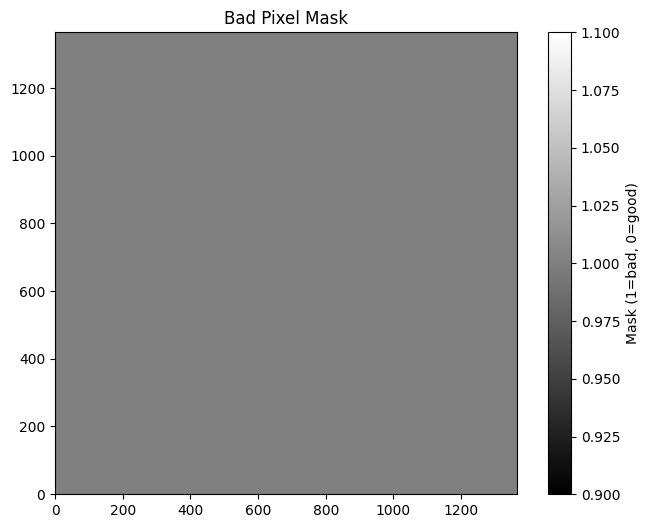

In [50]:
import os
from glob import glob
import numpy as np
from astropy.io import fits
from astropy import units as u
from ccdproc import CCDData, Combiner
import matplotlib.pyplot as plt

# ---- STEP 1: Find all FITS files and filter by OBSTYPE = FLAT ----

def is_flat_frame(filepath):
    try:
        with fits.open(filepath) as hdul:
            obstype = hdul[0].header.get('OBSTYPE', '').strip().upper()
            return 'FLAT' in obstype
    except Exception as e:
        print(f"Error reading {filepath}: {e}")
        return False

# ✅ Updated path and file extension
data_path = 'C:/Users/Observatory/Exo/Data/Standard-stars/BD+302428B/low'
all_files = glob(os.path.join(data_path, '*.fit'))
flat_files = [f for f in all_files if is_flat_frame(f)]

# ---- STEP 2: Load valid 2D CCDData images ----

valid_ccds = []
for f in flat_files:
    try:
        ccd = CCDData.read(f, unit='adu')
        if ccd.data is not None and ccd.data.ndim == 2:
            valid_ccds.append(ccd)
        else:
            print(f"Skipping {f}: invalid shape or missing data.")
    except Exception as e:
        print(f"Skipping {f}: {e}")

#print(f"Loaded {len(valid_ccds)} valid FLAT frames.")

# ---- STEP 3: Combine flats and compute pixel-wise standard deviation ----

if len(valid_ccds) < 2:
    raise ValueError("Not enough valid flat frames to combine.")

# Combine with median
combiner = Combiner(valid_ccds)
master_flat = combiner.median_combine()

# Stack all data into a 3D numpy array to compute stddev
stack = np.stack([ccd.data for ccd in valid_ccds])
stddev_image = np.std(stack, axis=0)

# ---- STEP 4: Create a bad pixel mask ----

flat_median = np.median(master_flat.data)
flat_std = np.std(master_flat.data)

# Mark pixels that are too noisy or deviate too much in brightness
bad_pixel_mask = (
    (stddev_image > 5 * flat_std) |
    (master_flat.data < 0.5 * flat_median) |
    (master_flat.data > 1.5 * flat_median)
)

# ---- STEP 5: Save the mask as FITS ----

mask_hdu = fits.PrimaryHDU(bad_pixel_mask.astype(np.uint8))
mask_hdu.writeto('bad_pixel_mask.fits', overwrite=True)
#print("Bad pixel mask saved to 'bad_pixel_mask.fits'")

# ---- STEP 6: Optional visualization ----

plt.figure(figsize=(8, 6))
plt.imshow(bad_pixel_mask, origin='lower', cmap='gray')
plt.title("Bad Pixel Mask")
plt.colorbar(label='Mask (1=bad, 0=good)')
plt.show()


Loaded 20 flat CCD frames.


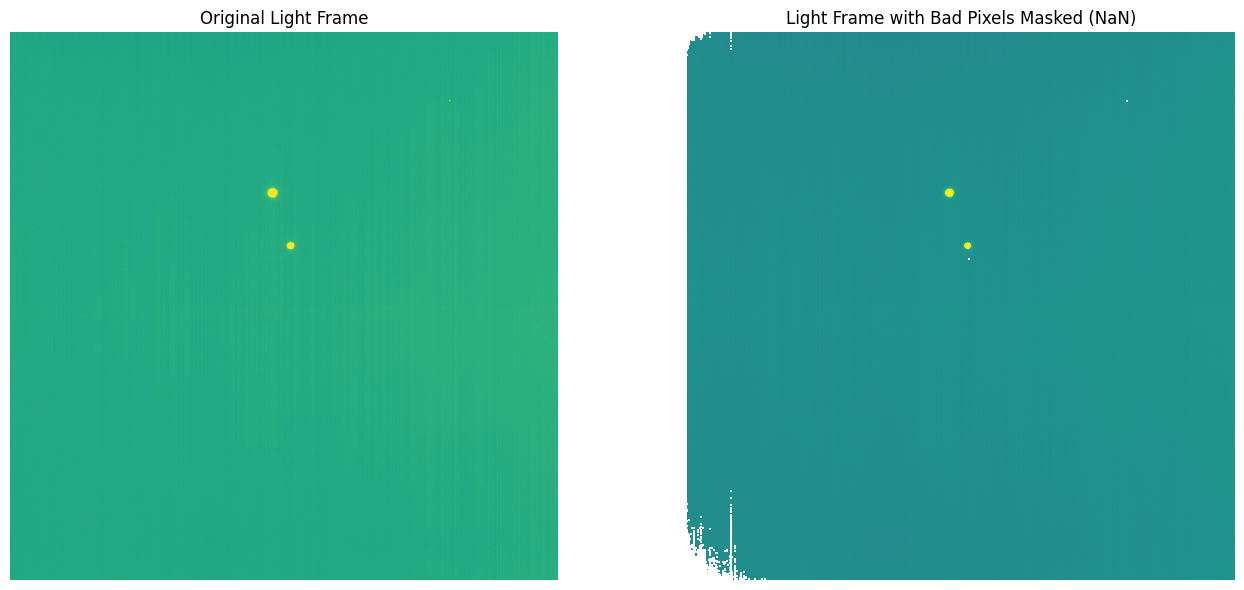

In [69]:
import logging
logging.getLogger('astropy').setLevel(logging.WARNING)

import os
from glob import glob
import numpy as np
import matplotlib.pyplot as plt

from astropy.nddata import CCDData
from ccdproc import Combiner
import astropy.units as u

# --- STEP 1: Define data path and file lists ---
data_path = 'C:/Users/Observatory/Exo/Data/Standard-stars/BD+302428B/low'

all_files = glob(os.path.join(data_path, '*.fit'))

flat_files = []
light_files = []

for f in all_files:
    try:
        header = CCDData.read(f, unit='adu').meta
        obstype = header.get('OBSTYPE', '').upper()
        if obstype == 'FLAT':
            flat_files.append(f)
        elif obstype == 'OBJECT':
            light_files.append(f)
    except Exception:
        pass  # silently skip files with header read errors

# --- STEP 2: Load flat frames ---
ccd_list = []
for f in flat_files:
    try:
        ccd = CCDData.read(f, unit='adu')
        ccd_list.append(ccd)
    except Exception:
        pass  # silently skip files with errors

print(f"Loaded {len(ccd_list)} flat CCD frames.")

# --- STEP 3: Combine flats to make master flat ---
combiner = Combiner(ccd_list)
master_flat = combiner.median_combine()

# Calculate stddev image manually:
data_stack = np.array([ccd.data for ccd in ccd_list])
stddev_image_data = np.std(data_stack, axis=0)

# --- STEP 4: Create bad pixel mask based on master flat ---
flat_median = np.median(master_flat.data)
flat_stddev = np.std(master_flat.data)

threshold = 3 * flat_stddev
bad_pixel_mask = (np.abs(master_flat.data - flat_median) > threshold)

def apply_bad_pixel_mask(ccd, mask):
    data_float = ccd.data.astype(float)
    data_float[mask] = np.nan
    return CCDData(data_float, meta=ccd.meta, unit=ccd.unit)

def crop_to_mask_size(ccd, target_shape):
    y, x = target_shape
    if ccd.data.shape != target_shape:
        # crop silently without print
        cropped_data = ccd.data[:y, :x].astype(float)
        return CCDData(cropped_data, meta=ccd.meta, unit=ccd.unit)
    else:
        return ccd

# --- STEP 5a: Load original light frames and crop if needed ---
light_ccds = []
for f in light_files:
    try:
        ccd = CCDData.read(f, unit='adu')
        ccd = crop_to_mask_size(ccd, bad_pixel_mask.shape)
        light_ccds.append(CCDData(ccd.data.astype(float), meta=ccd.meta, unit=ccd.unit))
    except Exception:
        pass  # silently skip bad files

# --- STEP 5b: Apply bad pixel mask to light frames ---
masked_light_ccds = [apply_bad_pixel_mask(ccd, bad_pixel_mask) for ccd in light_ccds]

# --- STEP 6: Plot original vs masked first light frame ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(light_ccds[0].data, origin='lower', cmap='viridis', vmin=10, vmax=100)
axes[0].set_title('Original Light Frame')
axes[0].set_axis_off()

axes[1].imshow(masked_light_ccds[0].data, origin='lower', cmap='viridis', vmin=10, vmax=120)
axes[1].set_title('Light Frame with Bad Pixels Masked (NaN)')
axes[1].set_axis_off()
plt.savefig('bad-pixel-from-flats.png', dpi=300)

plt.tight_layout()
plt.show()


Loaded 5 dark CCD frames.
Cropping CCD from shape (1366, 1366) to (1365, 1365)
Cropping CCD from shape (1366, 1366) to (1365, 1365)
Cropping CCD from shape (1366, 1366) to (1365, 1365)
Cropping CCD from shape (1366, 1366) to (1365, 1365)
Cropping CCD from shape (1366, 1366) to (1365, 1365)
Cropping CCD from shape (1366, 1366) to (1365, 1365)
Cropping CCD from shape (1366, 1366) to (1365, 1365)


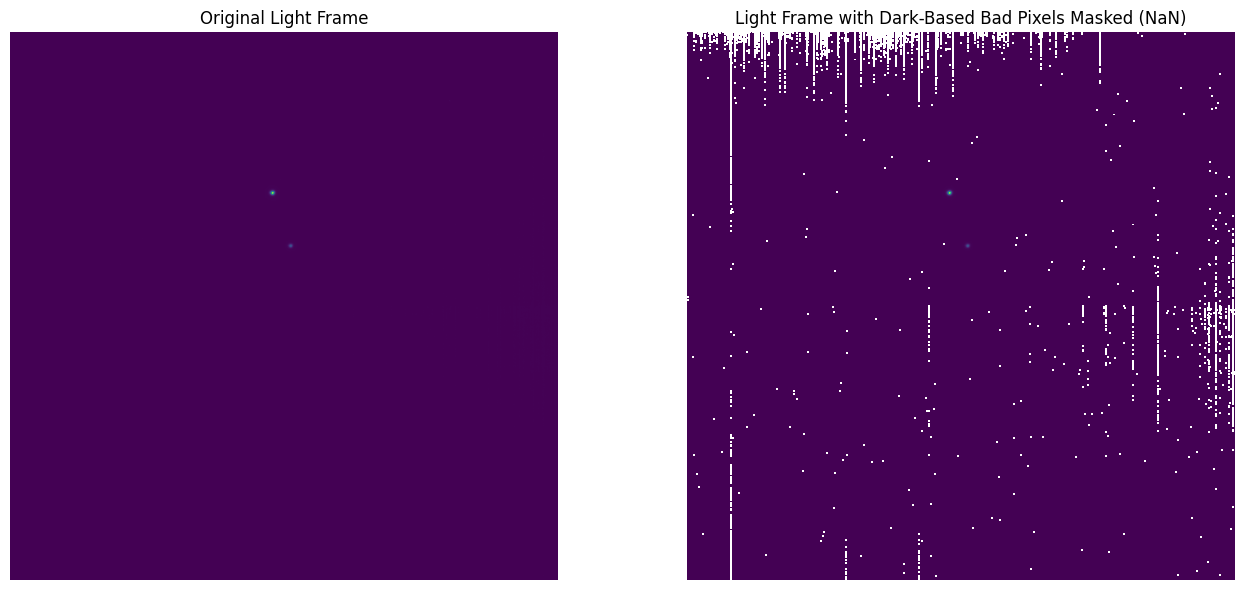

In [75]:
import os
from glob import glob
import numpy as np
import matplotlib.pyplot as plt

from astropy.nddata import CCDData
from ccdproc import Combiner
import astropy.units as u

data_path = 'C:/Users/Observatory/Exo/Data/Standard-stars/BD+302428B/low'

# --- Load files ---
all_files = glob(os.path.join(data_path, '*.fit'))

dark_files = []
light_files = []

for f in all_files:
    try:
        header = CCDData.read(f, unit='adu').meta
        obstype = header.get('OBSTYPE', '').upper()
        if obstype == 'DARK':
            dark_files.append(f)
        elif obstype == 'OBJECT':
            light_files.append(f)
    except Exception:
        pass  # silently ignore errors here

# --- Load dark frames ---
dark_ccds = []
for f in dark_files:
    try:
        ccd = CCDData.read(f, unit='adu')
        dark_ccds.append(ccd)
    except Exception:
        pass

print(f"Loaded {len(dark_ccds)} dark CCD frames.")

# --- Combine dark frames into master dark ---
combiner = Combiner(dark_ccds)
master_dark = combiner.median_combine()

# Calculate stddev image manually:
data_stack = np.array([ccd.data for ccd in dark_ccds])
stddev_image_data = np.std(data_stack, axis=0)

# --- Create bad pixel mask based on master dark ---
dark_median = np.median(master_dark.data)
dark_stddev = np.std(master_dark.data)

threshold = 3 * dark_stddev  # tweak this if needed
bad_pixel_mask_dark = (np.abs(master_dark.data - dark_median) > threshold)

def apply_bad_pixel_mask(ccd, mask):
    data_float = ccd.data.astype(float)
    data_float[mask] = np.nan
    return CCDData(data_float, meta=ccd.meta, unit=ccd.unit)

def crop_to_mask_size(ccd, target_shape):
    y, x = target_shape
    if ccd.data.shape != target_shape:
        print(f"Cropping CCD from shape {ccd.data.shape} to {target_shape}")
    cropped_data = ccd.data[:y, :x].astype(float)
    return CCDData(cropped_data, meta=ccd.meta, unit=ccd.unit)

# --- Load and prepare light frames ---
light_ccds = []
for f in light_files:
    try:
        ccd = CCDData.read(f, unit='adu')
        if ccd.data.shape != bad_pixel_mask_dark.shape:
            ccd = crop_to_mask_size(ccd, bad_pixel_mask_dark.shape)
        else:
            ccd = CCDData(ccd.data.astype(float), meta=ccd.meta, unit=ccd.unit)
        light_ccds.append(ccd)
    except Exception:
        pass

# --- Apply dark-based bad pixel mask to light frames ---
masked_light_ccds_dark = []
for ccd in light_ccds:
    masked_ccd = apply_bad_pixel_mask(ccd, bad_pixel_mask_dark)
    masked_light_ccds_dark.append(masked_ccd)

# --- Plot original vs dark-masked first light frame ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].imshow(light_ccds[0].data, origin='lower', cmap='viridis')
axes[0].set_title('Original Light Frame')
axes[0].set_axis_off()

axes[1].imshow(masked_light_ccds_dark[0].data, origin='lower', cmap='viridis')
axes[1].set_title('Light Frame with Dark-Based Bad Pixels Masked (NaN)')
axes[1].set_axis_off()
plt.savefig('hot-pixel-from-darks.png', dpi=300)

plt.tight_layout()
plt.show()
